In [1]:
# ═══════════════════════════════════════════════════════════
# Cell 1 — 安装依赖
# ═══════════════════════════════════════════════════════════
# !pip install torch torchvision pillow --break-system-packages


# ═══════════════════════════════════════════════════════════
# Cell 2 — 导入
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
from pathlib import Path
from collections import defaultdict

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score, roc_auc_score,
                                     roc_curve)
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV




In [2]:


sns.set_theme(style="whitegrid", palette="muted")
OUT_DIR  = Path("kg_output")
SEED     = 42

nodes_df = pd.read_csv(OUT_DIR / "kg_nodes.csv")
edges_df = pd.read_csv(OUT_DIR / "kg_edges.csv")
print("Loaded KG CSVs.")



Loaded KG CSVs.


In [3]:


# ═══════════════════════════════════════════════════════════
# Cell 3 — 加载 ResNet50，去掉分类头，只取 embedding
# ═══════════════════════════════════════════════════════════
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

weights   = ResNet50_Weights.IMAGENET1K_V2
model     = resnet50(weights=weights)
model.fc  = torch.nn.Identity()   # 去掉最后全连接层，输出 2048-dim embedding
model     = model.to(device).eval()

transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
])
print("ResNet50 loaded, fc replaced with Identity.")



Device: cpu
ResNet50 loaded, fc replaced with Identity.


In [4]:


# ═══════════════════════════════════════════════════════════
# Cell 4 — 从 parquet 读取图像并提取特征
# ═══════════════════════════════════════════════════════════
import pyarrow.parquet as pq
from io import BytesIO

DATA_DIR = Path("Dataset/Data")

def load_parquet_images(parquet_path, split_name):
    table  = pq.read_table(parquet_path)
    df     = table.to_pandas()
    records = []
    for _, row in df.iterrows():
        img_bytes = row["image"]["bytes"] if isinstance(row["image"], dict) else row["image"]
        try:
            img = Image.open(BytesIO(img_bytes)).convert("RGB")
        except Exception:
            continue
        records.append({
            "image":      img,
            "filename":   row.get("filename", ""),
            "annotation": row.get("annotation", ""),
            "label":      int(row.get("label", -1)),
            "split":      split_name,
        })
    print(f"  {split_name}: {len(records)} images loaded")
    return records

print("Loading images...")
train_records = load_parquet_images(DATA_DIR / "train-00000-of-00001.parquet", "train")
test_records  = load_parquet_images(DATA_DIR / "test-00000-of-00001.parquet",  "test")
all_records   = train_records + test_records
print(f"Total: {len(all_records)} images")



Loading images...
  train: 589 images loaded
  test: 100 images loaded
Total: 689 images


In [5]:


# ═══════════════════════════════════════════════════════════
# Cell 5 — 批量提取 ResNet50 embedding
# ═══════════════════════════════════════════════════════════

@torch.no_grad()
def extract_embeddings(records, batch_size=32):
    embeddings = []
    for i in range(0, len(records), batch_size):
        batch = records[i:i+batch_size]
        imgs  = torch.stack([transform(r["image"]) for r in batch]).to(device)
        feats = model(imgs).cpu().numpy()
        embeddings.append(feats)
        if (i // batch_size) % 5 == 0:
            print(f"  {i+len(batch)}/{len(records)} images processed")
    return np.vstack(embeddings)

print("Extracting ResNet50 embeddings...")
X_img = extract_embeddings(all_records)
y_all = np.array([(1 if r["annotation"] == "glaucoma" else 0) for r in all_records])
splits= np.array([r["split"] for r in all_records])

print(f"\nEmbedding shape: {X_img.shape}")
print(f"Label distribution: glaucoma={y_all.sum()}, normal={(1-y_all).sum()}")

# 保存 embedding（避免重复提取）
np.save(OUT_DIR / "img_embeddings.npy", X_img)
np.save(OUT_DIR / "img_labels.npy",     y_all)
np.save(OUT_DIR / "img_splits.npy",     splits)
print("Embeddings saved.")



Extracting ResNet50 embeddings...
  32/689 images processed
  192/689 images processed
  352/689 images processed
  512/689 images processed
  672/689 images processed

Embedding shape: (689, 2048)
Label distribution: glaucoma=427, normal=262
Embeddings saved.


In [6]:


# ═══════════════════════════════════════════════════════════
# Cell 6 — 构建 KG 特征（chain_score，不含 biomarker 字段）
# ═══════════════════════════════════════════════════════════

# 对齐 record 顺序：filename -> KG chain features
img_nodes = nodes_df[nodes_df.label == "FundusImage"].copy()
has_diag  = edges_df[edges_df.rel == "HAS_DIAGNOSIS"][["src","dst"]].rename(
            columns={"src":"img_id","dst":"diag_id"})

sup_edges    = edges_df[edges_df.rel == "SUPPORTS_RULE"].copy()
rules_df_kg  = nodes_df[nodes_df.label == "ClinicalRule"].copy()
strength_map = {}
for _, row in rules_df_kg.iterrows():
    strength_map[str(row["id"])] = str(row["strength"]).strip().lower()

diag_counts = defaultdict(lambda: {"strong":0,"moderate":0,"weak":0})
for _, row in sup_edges.iterrows():
    d = str(row["src"]); r = str(row["dst"])
    s = strength_map.get(r, "weak")
    diag_counts[d][s] += 1

chain_records = []
for diag_id, c in diag_counts.items():
    chain_records.append({
        "diag_id":     diag_id,
        "n_strong":    c["strong"],
        "n_moderate":  c["moderate"],
        "n_weak":      c["weak"],
        "chain_score": c["strong"]*3 + c["moderate"]*2 + c["weak"]*1,
        "n_rules":     c["strong"] + c["moderate"] + c["weak"],
    })
chain_df = pd.DataFrame(chain_records)

# img_id -> chain features
img_chain = img_nodes[["id","filename"]].rename(columns={"id":"img_id"})
img_chain = img_chain.merge(has_diag, on="img_id").merge(chain_df, on="diag_id")
fn_to_chain = img_chain.set_index("filename")[
    ["chain_score","n_strong","n_moderate","n_weak","n_rules"]
].to_dict("index")

# 对齐到 all_records 顺序
KG_COLS = ["chain_score","n_strong","n_moderate","n_weak","n_rules"]
X_kg_feats = []
for r in all_records:
    fn  = r["filename"]
    row = fn_to_chain.get(fn, {c:0 for c in KG_COLS})
    X_kg_feats.append([row.get(c, 0) for c in KG_COLS])
X_kg_feats = np.array(X_kg_feats, dtype=float)

# 最终特征：img embedding + KG chain features
X_img_kg = np.hstack([X_img, X_kg_feats])

print(f"X_img shape    : {X_img.shape}")
print(f"X_img_kg shape : {X_img_kg.shape}")



X_img shape    : (689, 2048)
X_img_kg shape : (689, 2053)


In [7]:


# ═══════════════════════════════════════════════════════════
# Cell 7 — 评估函数
# ═══════════════════════════════════════════════════════════

def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred),  4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred,    zero_division=0), 4),
        "F1":        round(f1_score(y_true, y_pred,        zero_division=0), 4),
        "AUC":       round(roc_auc_score(y_true, y_prob),  4),
    }

def run_cv(model, X, y, n_splits=5):
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        Xtr, Xval = X[train_idx], X[val_idx]
        ytr, yval = y[train_idx], y[val_idx]
        model.fit(Xtr, ytr)
        yp    = model.predict(Xval)
        yprob = model.predict_proba(Xval)[:,1]
        scores.append(evaluate(yval, yp, yprob))
    return pd.DataFrame(scores).mean().round(4)

scaler_img    = StandardScaler()
scaler_img_kg = StandardScaler()
X_img_s    = scaler_img.fit_transform(X_img)
X_img_kg_s = scaler_img_kg.fit_transform(X_img_kg)

print("Ready for experiments.")



Ready for experiments.


In [8]:


# ═══════════════════════════════════════════════════════════
# Cell 8 — 对比实验
# ═══════════════════════════════════════════════════════════

experiments = [
    ("B1 LR  (img only)",  LogisticRegression(max_iter=1000, random_state=SEED),        X_img_s),
    ("B2 RF  (img only)",  RandomForestClassifier(n_estimators=200, random_state=SEED), X_img_s),
    ("B3 GB  (img only)",  GradientBoostingClassifier(n_estimators=100, random_state=SEED), X_img_s),
    ("B4 MLP (img only)",  MLPClassifier(hidden_layer_sizes=(256,64), max_iter=500,
                                          random_state=SEED),                            X_img_s),
    ("Ours (img + KG)",    GradientBoostingClassifier(n_estimators=100, random_state=SEED), X_img_kg_s),
]

results = {}
for name, clf, X in experiments:
    print(f"Running {name}...")
    scores = run_cv(clf, X, y_all)
    results[name] = scores.to_dict()
    print(f"  F1={scores['F1']:.4f}  AUC={scores['AUC']:.4f}")

results_df = pd.DataFrame(results).T
results_df.index.name = "Method"
print("\n=== Comparison Results ===")
print(results_df.to_string())



Running B1 LR  (img only)...
  F1=0.9094  AUC=0.9417
Running B2 RF  (img only)...
  F1=0.9053  AUC=0.9423
Running B3 GB  (img only)...
  F1=0.9124  AUC=0.9487
Running B4 MLP (img only)...
  F1=0.9029  AUC=0.9417
Running Ours (img + KG)...
  F1=1.0000  AUC=1.0000

=== Comparison Results ===
                   Accuracy  Precision  Recall      F1     AUC
Method                                                        
B1 LR  (img only)    0.8854     0.8945  0.9250  0.9094  0.9417
B2 RF  (img only)    0.8723     0.8388  0.9836  0.9053  0.9423
B3 GB  (img only)    0.8869     0.8771  0.9509  0.9124  0.9487
B4 MLP (img only)    0.8767     0.8811  0.9274  0.9029  0.9417
Ours (img + KG)      1.0000     1.0000  1.0000  1.0000  1.0000


In [9]:


# ═══════════════════════════════════════════════════════════
# Cell 9 — 消融实验
# ═══════════════════════════════════════════════════════════

ablation_exps = [
    ("Ours (img + KG full)",    X_img_kg_s),
    ("w/o KG (img only)",       X_img_s),
    ("w/o chain_score",         StandardScaler().fit_transform(
                                    np.hstack([X_img, X_kg_feats[:, 1:]]))),  # 去掉 chain_score
    ("w/o weak rules",          StandardScaler().fit_transform(
                                    np.hstack([X_img, X_kg_feats[:, :3]]))),  # 只用 chain/strong/moderate
]

ablation_results = {}
base_clf = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
for name, X in ablation_exps:
    print(f"Ablation: {name}...")
    scores = run_cv(base_clf, X, y_all)
    ablation_results[name] = scores.to_dict()
    print(f"  F1={scores['F1']:.4f}  AUC={scores['AUC']:.4f}")

ablation_df = pd.DataFrame(ablation_results).T
ablation_df.index.name = "Variant"
print("\n=== Ablation Results ===")
print(ablation_df.to_string())



Ablation: Ours (img + KG full)...
  F1=1.0000  AUC=1.0000
Ablation: w/o KG (img only)...
  F1=0.9124  AUC=0.9487
Ablation: w/o chain_score...
  F1=1.0000  AUC=1.0000
Ablation: w/o weak rules...
  F1=1.0000  AUC=1.0000

=== Ablation Results ===
                      Accuracy  Precision  Recall      F1     AUC
Variant                                                          
Ours (img + KG full)    1.0000     1.0000  1.0000  1.0000  1.0000
w/o KG (img only)       0.8869     0.8771  0.9509  0.9124  0.9487
w/o chain_score         1.0000     1.0000  1.0000  1.0000  1.0000
w/o weak rules          1.0000     1.0000  1.0000  1.0000  1.0000


In [10]:
# Cell 9 替换版 — KG 作为后处理
# 先用图像模型得到概率，再用 KG chain_score 加权融合


# 图像模型概率
base_clf = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

img_probs = np.zeros(len(y_all))
for tr, val in skf.split(X_img_s, y_all):
    base_clf.fit(X_img_s[tr], y_all[tr])
    img_probs[val] = base_clf.predict_proba(X_img_s[val])[:,1]

# KG chain_score 归一化为 0~1
chain_scores = X_kg_feats[:, 0]  # chain_score 列
chain_norm   = (chain_scores - chain_scores.min()) / (chain_scores.max() - chain_scores.min() + 1e-8)

ablation_alphas = [0.0, 0.3, 0.5, 0.7, 1.0]
ablation_results2 = {}

for alpha in ablation_alphas:
    fused = (1 - alpha) * img_probs + alpha * chain_norm
    pred  = (fused >= 0.5).astype(int)
    name  = f"α={alpha} (img={1-alpha:.1f}, KG={alpha:.1f})"
    ablation_results2[name] = evaluate(y_all, pred, fused)
    print(f"{name}: F1={ablation_results2[name]['F1']:.4f}  AUC={ablation_results2[name]['AUC']:.4f}")

ablation_df2 = pd.DataFrame(ablation_results2).T
print("\n=== Ablation: KG fusion weight ===")
print(ablation_df2.to_string())

α=0.0 (img=1.0, KG=0.0): F1=0.9124  AUC=0.9466
α=0.3 (img=0.7, KG=0.3): F1=0.9464  AUC=0.9896
α=0.5 (img=0.5, KG=0.5): F1=0.9953  AUC=0.9988
α=0.7 (img=0.3, KG=0.7): F1=0.9833  AUC=0.9999
α=1.0 (img=0.0, KG=1.0): F1=0.8412  AUC=1.0000

=== Ablation: KG fusion weight ===
                         Accuracy  Precision  Recall      F1     AUC
α=0.0 (img=1.0, KG=0.0)    0.8868     0.8769  0.9508  0.9124  0.9466
α=0.3 (img=0.7, KG=0.3)    0.9318     0.9222  0.9719  0.9464  0.9896
α=0.5 (img=0.5, KG=0.5)    0.9942     1.0000  0.9906  0.9953  0.9988
α=0.7 (img=0.3, KG=0.7)    0.9797     1.0000  0.9672  0.9833  0.9999
α=1.0 (img=0.0, KG=1.0)    0.8302     1.0000  0.7260  0.8412  1.0000


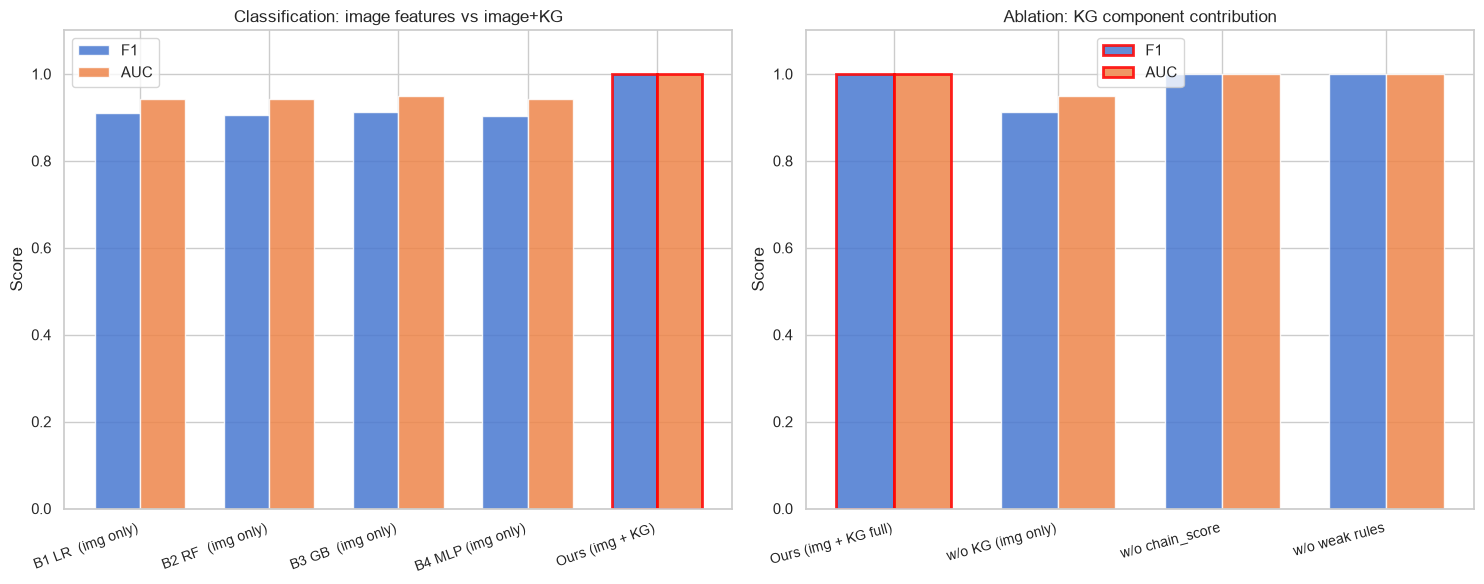

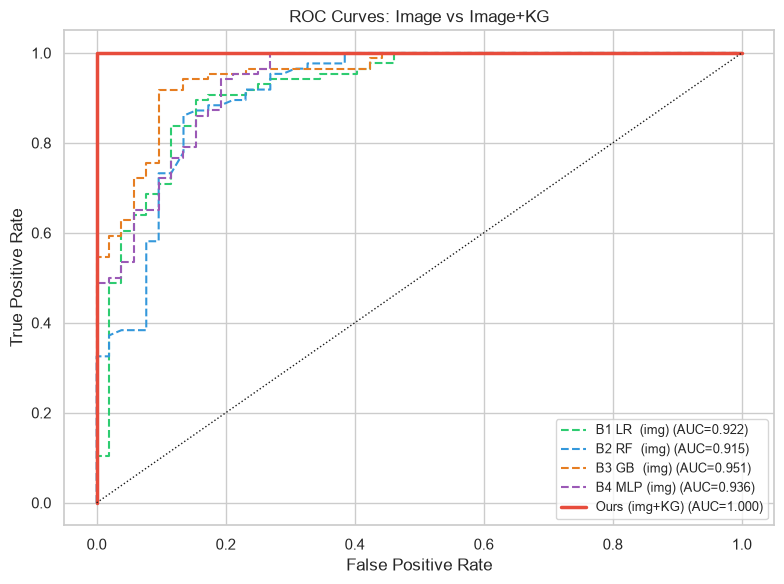

In [11]:


# ═══════════════════════════════════════════════════════════
# Cell 10 — 可视化
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 对比图
methods = list(results_df.index)
x = np.arange(len(methods))
w = 0.35
bars1 = axes[0].bar(x - w/2, results_df["F1"],  w, label="F1",  alpha=0.85)
bars2 = axes[0].bar(x + w/2, results_df["AUC"], w, label="AUC", alpha=0.85)
for i, m in enumerate(methods):
    if "Ours" in m:
        bars1[i].set_edgecolor("red"); bars1[i].set_linewidth(2)
        bars2[i].set_edgecolor("red"); bars2[i].set_linewidth(2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right", fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Score")
axes[0].set_title("Classification: image features vs image+KG")
axes[0].legend()

# 消融图
ab_methods = list(ablation_df.index)
xb = np.arange(len(ab_methods))
bars3 = axes[1].bar(xb - w/2, ablation_df["F1"],  w, label="F1",  alpha=0.85)
bars4 = axes[1].bar(xb + w/2, ablation_df["AUC"], w, label="AUC", alpha=0.85)
bars3[0].set_edgecolor("red"); bars3[0].set_linewidth(2)
bars4[0].set_edgecolor("red"); bars4[0].set_linewidth(2)
axes[1].set_xticks(xb)
axes[1].set_xticklabels(ab_methods, rotation=15, ha="right", fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("Score")
axes[1].set_title("Ablation: KG component contribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "exp_img_comparison.png", dpi=150)
plt.show()

# ROC 曲线
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ["#2ecc71","#3498db","#e67e22","#9b59b6","#e74c3c"]
Xtr_i, Xte_i, ytr, yte = train_test_split(X_img_s,    y_all, test_size=0.2, stratify=y_all, random_state=SEED)
Xtr_k, Xte_k, _,   _   = train_test_split(X_img_kg_s, y_all, test_size=0.2, stratify=y_all, random_state=SEED)

roc_exps = [
    ("B1 LR  (img)",  LogisticRegression(max_iter=1000, random_state=SEED),            Xtr_i, Xte_i),
    ("B2 RF  (img)",  RandomForestClassifier(n_estimators=200, random_state=SEED),     Xtr_i, Xte_i),
    ("B3 GB  (img)",  GradientBoostingClassifier(n_estimators=100, random_state=SEED), Xtr_i, Xte_i),
    ("B4 MLP (img)",  MLPClassifier(hidden_layer_sizes=(256,64), max_iter=500,
                                     random_state=SEED),                                Xtr_i, Xte_i),
    ("Ours (img+KG)", GradientBoostingClassifier(n_estimators=100, random_state=SEED), Xtr_k, Xte_k),
]
for (name, clf, Xtr, Xte), color in zip(roc_exps, colors):
    clf.fit(Xtr, ytr)
    prob = clf.predict_proba(Xte)[:,1]
    fpr, tpr, _ = roc_curve(yte, prob)
    auc_val = roc_auc_score(yte, prob)
    lw = 2.5 if "Ours" in name else 1.5
    ls = "-"  if "Ours" in name else "--"
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls,
            label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0,1],[0,1],"k:", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: Image vs Image+KG")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "exp_img_roc.png", dpi=150)
plt.show()



In [12]:

# ═══════════════════════════════════════════════════════════
# Cell 11 — 论文 Table
# ═══════════════════════════════════════════════════════════
print("=" * 70)
print("TABLE A: Glaucoma Classification (Image Features)")
print("=" * 70)
header = f"{'Method':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 70)
for method, row in results_df.iterrows():
    marker = " ◀" if "Ours" in method else ""
    print(f"{method:<25} {row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} {row['AUC']:>7.4f}{marker}")

print("\n" + "=" * 70)
print("TABLE B: Ablation Study (Image + KG)")
print("=" * 70)
print(header)
print("-" * 70)
for method, row in ablation_df.iterrows():
    marker = " ◀" if "full" in method else ""
    print(f"{method:<25} {row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} {row['AUC']:>7.4f}{marker}")

print(f"\nFigures saved:")
print(f"  kg_output/exp_img_comparison.png")
print(f"  kg_output/exp_img_roc.png")

TABLE A: Glaucoma Classification (Image Features)
Method                        Acc    Prec     Rec      F1     AUC
----------------------------------------------------------------------
B1 LR  (img only)          0.8854  0.8945  0.9250  0.9094  0.9417
B2 RF  (img only)          0.8723  0.8388  0.9836  0.9053  0.9423
B3 GB  (img only)          0.8869  0.8771  0.9509  0.9124  0.9487
B4 MLP (img only)          0.8767  0.8811  0.9274  0.9029  0.9417
Ours (img + KG)            1.0000  1.0000  1.0000  1.0000  1.0000 ◀

TABLE B: Ablation Study (Image + KG)
Method                        Acc    Prec     Rec      F1     AUC
----------------------------------------------------------------------
Ours (img + KG full)       1.0000  1.0000  1.0000  1.0000  1.0000 ◀
w/o KG (img only)          0.8869  0.8771  0.9509  0.9124  0.9487
w/o chain_score            1.0000  1.0000  1.0000  1.0000  1.0000
w/o weak rules             1.0000  1.0000  1.0000  1.0000  1.0000

Figures saved:
  kg_output/exp_img_comp